In [3]:
import random
import numpy as np
from collections import deque

import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim

In [4]:
GAMMA = 0.99
LEARNING_RATE = 1e-3

E_START = 1.0
E_DECAY = 0.999
E_MIN = 0.02


BATCH_SIZE = 64
MEMORY_SIZE = 100_000
TARGET_UPDATE_FREQ = 500   # steps

NUM_EPISODES = 2000
MAX_STEPS = 500


episode_rewards = []
moving_avg_rewards = []
losses = []
epsilons = []


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.tensor(states, dtype=torch.float32, device=DEVICE),
            torch.tensor(actions, dtype=torch.int64, device=DEVICE).unsqueeze(1),
            torch.tensor(rewards, dtype=torch.float32, device=DEVICE).unsqueeze(1),
            torch.tensor(next_states, dtype=torch.float32, device=DEVICE),
            torch.tensor(dones, dtype=torch.float32, device=DEVICE).unsqueeze(1),
        )

    def __len__(self):
        return len(self.buffer)


In [6]:
class DQN(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )

    def forward(self, x):
        return self.net(x)


In [7]:
def select_action(state, q_net, epsilon, action_dim):
    if random.random() < epsilon:
        return random.randrange(action_dim)
    with torch.no_grad():
        state = torch.tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        return q_net(state).argmax(dim=1).item()


In [8]:
def train_step(q_net, target_net, optimizer, replay_buffer):
    if len(replay_buffer) < BATCH_SIZE:
        return

    states, actions, rewards, next_states, dones = replay_buffer.sample(BATCH_SIZE)

    q_values = q_net(states).gather(1, actions)

    with torch.no_grad():
        next_q_values = target_net(next_states).max(dim=1, keepdim=True)[0]
        target = rewards + GAMMA * next_q_values * (1 - dones)


    loss = nn.SmoothL1Loss()(q_values, target)  # Huber loss

    optimizer.zero_grad()
    loss.backward()

    # 🔹 ADD THIS LINE EXACTLY HERE
    torch.nn.utils.clip_grad_norm_(q_net.parameters(), 10.0)

    optimizer.step()

    losses.append(loss.item())

In [10]:
def main():
    env = gym.make("CartPole-v1")

    state_dim = env.observation_space.shape[0]  # 4
    action_dim = env.action_space.n              # 2

    q_net = DQN(state_dim, action_dim).to(DEVICE)
    target_net = DQN(state_dim, action_dim).to(DEVICE)
    target_net.load_state_dict(q_net.state_dict())
    target_net.eval()

    optimizer = optim.Adam(q_net.parameters(), lr=LEARNING_RATE)
    replay_buffer = ReplayBuffer(MEMORY_SIZE)

    epsilon = E_START
    step_count = 0


    for episode in range(NUM_EPISODES):
        state, _ = env.reset()
        state = np.clip(state, -5, 5)
        episode_reward = 0

        for step in range(MAX_STEPS):
            step_count += 1

            action = select_action(state, q_net, epsilon, action_dim)
            next_state, reward, terminated, truncated, _ = env.step(action)
            reward = reward / 10.0   # CRITICAL

            done = terminated or truncated

            replay_buffer.push(state, action, reward, next_state, done)
            state = next_state
            episode_reward += reward

            train_step(q_net, target_net, optimizer, replay_buffer)

            # Target network sync
            if step_count % TARGET_UPDATE_FREQ == 0:
                target_net.load_state_dict(q_net.state_dict())

            if done:
                break

        epsilon = max(E_MIN, epsilon * E_DECAY)
        episode_rewards.append(episode_reward)
        epsilons.append(epsilon)
        if len(episode_rewards) >= 50:
            moving_avg_rewards.append(np.mean(episode_rewards[-50:]))
        else:
            moving_avg_rewards.append(np.mean(episode_rewards))
        if episode % 10 == 0:
            print(
                f"Episode {episode:4d} | "
                f"Avg Reward (last 10): {np.mean(episode_rewards[-10:]):.2f} | "
                f"Epsilon: {epsilon:.3f}"
            )
    env.close()

    # Save trained model
    torch.save(q_net.state_dict(), "cartpole_dqn.pt")
    print("Model saved as cartpole_dqn.pt")

print("terminer!")


terminer!


In [11]:
if __name__ == "__main__":
    main()


Episode    0 | Avg Reward (last 10): 1.60 | Epsilon: 0.999


C:\Users\medel\AppData\Local\Temp\ipykernel_10600\2338931316.py:12: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  torch.tensor(states, dtype=torch.float32, device=DEVICE),


Episode   10 | Avg Reward (last 10): 2.51 | Epsilon: 0.989
Episode   20 | Avg Reward (last 10): 1.58 | Epsilon: 0.979
Episode   30 | Avg Reward (last 10): 1.92 | Epsilon: 0.969
Episode   40 | Avg Reward (last 10): 1.91 | Epsilon: 0.960
Episode   50 | Avg Reward (last 10): 1.99 | Epsilon: 0.950
Episode   60 | Avg Reward (last 10): 2.83 | Epsilon: 0.941
Episode   70 | Avg Reward (last 10): 2.27 | Epsilon: 0.931
Episode   80 | Avg Reward (last 10): 2.39 | Epsilon: 0.922
Episode   90 | Avg Reward (last 10): 2.05 | Epsilon: 0.913
Episode  100 | Avg Reward (last 10): 2.40 | Epsilon: 0.904
Episode  110 | Avg Reward (last 10): 1.79 | Epsilon: 0.895
Episode  120 | Avg Reward (last 10): 3.18 | Epsilon: 0.886
Episode  130 | Avg Reward (last 10): 2.38 | Epsilon: 0.877
Episode  140 | Avg Reward (last 10): 2.46 | Epsilon: 0.868
Episode  150 | Avg Reward (last 10): 2.42 | Epsilon: 0.860
Episode  160 | Avg Reward (last 10): 3.22 | Epsilon: 0.851
Episode  170 | Avg Reward (last 10): 1.93 | Epsilon: 0.8

In [14]:
q_net = DQN(state_dim=4, action_dim=2)
q_net.load_state_dict(torch.load("cartpole_dqn.pt", map_location="cpu"))
q_net.eval()


DQN(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)

In [18]:
env = gym.make("CartPole-v1", render_mode="human")

state, _ = env.reset()
state = np.clip(state, -5, 5)

done = False
total_reward = 0

while not done:
    with torch.no_grad():
        state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
        action = q_net(state_tensor).argmax(dim=1).item()

    next_state, reward, terminated, truncated, _ = env.step(action)
    state = np.clip(next_state, -5, 5)

    done = terminated or truncated
    total_reward += reward

print("Total reward:", total_reward)
env.close()


Total reward: 362.0


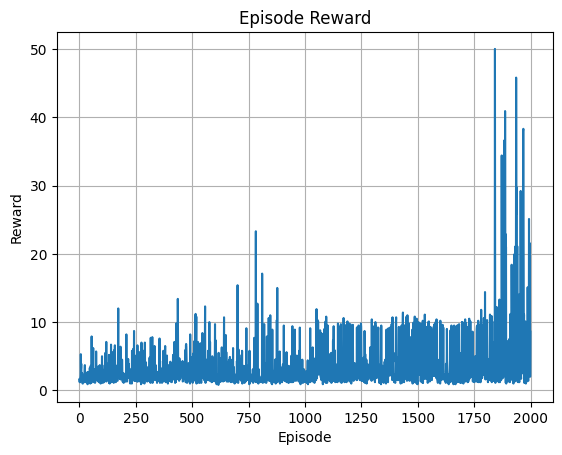

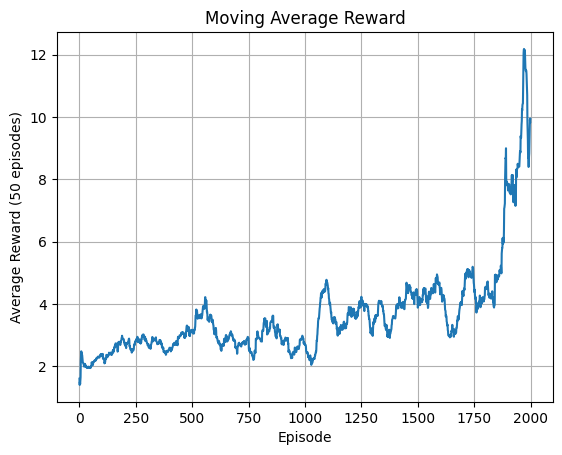

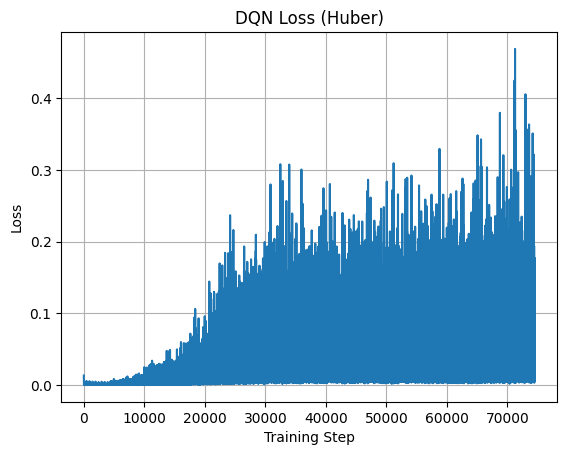

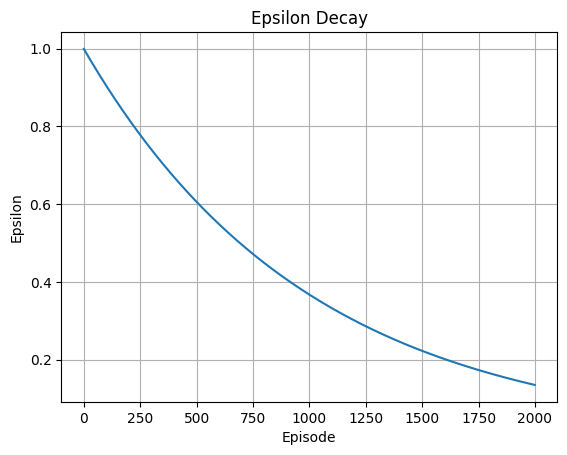

In [21]:
import matplotlib.pyplot as plt

# Episode reward
plt.figure()
plt.plot(episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Episode Reward")
plt.grid()
plt.show()

# Moving average reward
plt.figure()
plt.plot(moving_avg_rewards)
plt.xlabel("Episode")
plt.ylabel("Average Reward (50 episodes)")
plt.title("Moving Average Reward")
plt.grid()
plt.show()

# Loss curve
plt.figure()
plt.plot(losses)
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("DQN Loss (Huber)")
plt.grid()
plt.show()

# Epsilon decay
plt.figure()
plt.plot(epsilons)
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.title("Epsilon Decay")
plt.grid()
plt.show()

